# Embedding Benchmark — scJDO Drift-Field Pipeline

Benchmarks **8 latent-space methods** for the scJDO drift-field pipeline on the
bone marrow hematopoiesis dataset (`marrow_sample_scseq_counts.h5ad`).

## Methods compared (N_LATENT = 20 for all)

| Method | Library | Stochastic | Gene loadings |
|--------|---------|------------|---------------|
| **PCA** | sklearn | No | `varm["PCs"]` |
| FactorAnalysis | sklearn | Yes | components_.T |
| ICA | sklearn FastICA | Yes | mixing_ |
| TruncatedSVD | sklearn | No | components_.T |
| DiffMap | scanpy | No | Ridge regression |
| LDVAE | scvi LinearSCVI | Yes | get_loadings() |
| scVI | scvi SCVI | Yes | Ridge regression |
| PLS | sklearn PLSRegression | No | x_loadings_ |

## Fixed reference
Palantir pseudotime and branch masks are computed **once** on PCA coordinates and
shared across all 8 methods. Methods are scored on 5 dimensions:
marker enrichment, branch specificity, stability, timing spread, fit R².

**Dataset:** `marrow_sample_scseq_counts.h5ad` — 4,142 cells, 16,106 genes  
**Lineages:** Erythroid (Ery), Dendritic Cell (DC), Monocyte (Mono)

In [11]:
import sys, os, warnings, copy
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import palantir
import scjdo as sjd

# ── Output directories ─────────────────────────────────────────────────────
OUTDIR = 'results/benchmark/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Palantir fixed parameters ──────────────────────────────────────────────
START_CELL      = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                    'Mono',                   'Ery'],
    index=['Run5_131097901611291', 'Run5_134936662236454', 'Run4_200562869397916']
)
N_WAYPOINTS = 500

# ── Benchmark config ───────────────────────────────────────────────────────
N_LATENT    = 20
N_HVG       = 1500
BRANCHES    = ['Ery', 'DC', 'Mono']
BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}

# QUICK_RUN=True  → 500 epochs, 2 seeds  (fast, for CI / exploration)
# QUICK_RUN=False → 5000 epochs, 5 seeds (publication quality)
QUICK_RUN = True

if QUICK_RUN:
    N_EPOCHS = 500
    N_SEEDS  = 2
else:
    N_EPOCHS = 5000
    N_SEEDS  = 5

# scJDO drift-field parameters (shared across all methods)
N_ARCHETYPES  = 5
BIAS_STRENGTH = 1.5
BASE_SEED     = 42

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')
print(f'QUICK_RUN={QUICK_RUN} | N_EPOCHS={N_EPOCHS} | N_SEEDS={N_SEEDS} | N_LATENT={N_LATENT}')

scjdo  v0.3.0
palantir v1.4.4
QUICK_RUN=True | N_EPOCHS=500 | N_SEEDS=2 | N_LATENT=20


In [12]:
# ── Canonical marker panels ────────────────────────────────────────────────
MARKERS = {
    'Ery':  ['GATA1', 'KLF1', 'BLVRB', 'ALAS2', 'ERMAP', 'HBB', 'SLC40A1'],
    'DC':   ['IRF8', 'ZBTB46', 'FLT3', 'ITGAX', 'CLEC10A', 'BATF3'],
    'Mono': ['LYZ', 'LST1', 'FCN1', 'S100A8', 'S100A9', 'CTSS', 'SPI1'],
}

# ── Scoring functions ──────────────────────────────────────────────────────

def score_marker_enrichment(branch_results, top_n=30):
    """
    Fraction of top-N instability genes matching canonical markers.
    Returns per-branch dict and mean score.
    """
    per_branch = {}
    for branch in BRANCHES:
        res = branch_results.get(branch)
        if res is None:
            per_branch[branch] = 0.0
            continue
        genes = res.get('top_instability_genes', [])
        if len(genes) == 0:
            per_branch[branch] = 0.0
            continue
        top_genes = [g.upper() for g in genes[:top_n]]
        markers   = [m.upper() for m in MARKERS.get(branch, [])]
        hits      = len(set(top_genes) & set(markers))
        per_branch[branch] = hits / len(markers) if markers else 0.0
    return per_branch, float(np.mean(list(per_branch.values())))


def score_branch_specificity(branch_results, top_n=20):
    """
    1 - mean_pairwise_Jaccard(top-N gene sets across branches).
    Returns 0 if any branch has 0 instability genes.
    """
    gene_sets = {}
    for branch in BRANCHES:
        res = branch_results.get(branch)
        if res is None:
            return 0.0
        genes = res.get('top_instability_genes', [])
        if len(genes) == 0:
            return 0.0
        gene_sets[branch] = set(g.upper() for g in genes[:top_n])

    pairs    = []
    branches = list(gene_sets.keys())
    for i in range(len(branches)):
        for j in range(i + 1, len(branches)):
            a, b = gene_sets[branches[i]], gene_sets[branches[j]]
            union = len(a | b)
            inter = len(a & b)
            jacc  = inter / union if union > 0 else 0.0
            pairs.append(jacc)
    if not pairs:
        return 1.0
    return float(1.0 - np.mean(pairs))


def score_stability(seed_results):
    """
    1 / (1 + mean_std_of_peak_t_across_seeds).
    Deterministic methods (1 seed) return 1.0.
    `seed_results` is a list of branch_results dicts, one per seed.
    """
    if len(seed_results) <= 1:
        return 1.0

    branch_peak_ts = {b: [] for b in BRANCHES}
    for sr in seed_results:
        for branch in BRANCHES:
            res = sr.get(branch)
            if res is None:
                branch_peak_ts[branch].append(np.nan)
                continue
            t_centers = res.get('t_centers', np.array([0.5]))
            max_eig   = res.get('max_real_eig', np.zeros(len(t_centers)))
            peak_t    = float(t_centers[np.argmax(max_eig)])
            branch_peak_ts[branch].append(peak_t)

    stds = []
    for branch, pts in branch_peak_ts.items():
        arr = np.array(pts)
        arr = arr[~np.isnan(arr)]
        if len(arr) > 1:
            stds.append(float(np.std(arr)))
    mean_std = float(np.mean(stds)) if stds else 0.0
    return float(1.0 / (1.0 + mean_std))


def score_timing_spread(branch_results):
    """
    std of peak_t across branches, normalized: min(std / 0.5, 1.0).
    More temporal separation between lineage bifurcations = higher score.
    """
    peak_ts = []
    for branch in BRANCHES:
        res = branch_results.get(branch)
        if res is None:
            continue
        t_centers = res.get('t_centers', np.array([0.5]))
        max_eig   = res.get('max_real_eig', np.zeros(len(t_centers)))
        peak_ts.append(float(t_centers[np.argmax(max_eig)]))
    if len(peak_ts) < 2:
        return 0.0
    return float(min(np.std(peak_ts) / 0.5, 1.0))


def score_fit_r2(branch_results):
    """
    Mean R² across branches from scJDO archetype decomposition.
    """
    r2s = []
    for branch in BRANCHES:
        res = branch_results.get(branch)
        if res is None:
            continue
        r2s.append(float(res.get('r2', 0.0)))
    return float(np.mean(r2s)) if r2s else 0.0


def composite_score(marker, specificity, stability, timing, r2):
    """
    Weighted composite score.
    Weights: marker=30%, specificity=20%, stability=20%, timing=15%, r2=15%
    """
    return (0.30 * marker +
            0.20 * specificity +
            0.20 * stability +
            0.15 * timing +
            0.15 * r2)


print('Marker panels and scoring functions defined.')
for branch, marks in MARKERS.items():
    print(f'  {branch}: {marks}')

Marker panels and scoring functions defined.
  Ery: ['GATA1', 'KLF1', 'BLVRB', 'ALAS2', 'ERMAP', 'HBB', 'SLC40A1']
  DC: ['IRF8', 'ZBTB46', 'FLT3', 'ITGAX', 'CLEC10A', 'BATF3']
  Mono: ['LYZ', 'LST1', 'FCN1', 'S100A8', 'S100A9', 'CTSS', 'SPI1']


In [13]:
# ── Load raw data ──────────────────────────────────────────────────────────
ad = sc.read(os.path.join('./', 'marrow_sample_scseq_counts.h5ad'))
print(f'Loaded: {ad.n_obs} cells x {ad.n_vars} genes')

# Store raw counts (needed for scVI / LDVAE)
ad.layers['raw_counts'] = ad.X.copy()

# Normalize + log (Palantir convention, pseudocount=0.1)
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# ── HVG selection ─────────────────────────────────────────────────────────
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')
print(f'HVGs selected: {ad.var.highly_variable.sum()}')

# Keep HVG-only AnnData for gene-expression-based methods
ad_hvg = ad[:, ad.var.highly_variable].copy()
X_hvg  = ad_hvg.X.toarray() if hasattr(ad_hvg.X, 'toarray') else np.array(ad_hvg.X)
print(f'X_hvg shape: {X_hvg.shape}')

# ── HVG-only PCA — fair baseline for all methods ──────────────────────────
sc.pp.pca(ad_hvg, n_comps=N_LATENT)
print(f'HVG PCA computed: varm["PCs"] shape = {ad_hvg.varm["PCs"].shape}')

# ── Scanpy DiffMap on HVG subset (fair comparison — same 1500-gene space) ──
sc.pp.neighbors(ad_hvg, n_neighbors=30, n_pcs=N_LATENT)
sc.tl.diffmap(ad_hvg, n_comps=N_LATENT + 1)  # +1 because DC0 is trivially uniform
print(f'Scanpy DiffMap: X_diffmap={ad_hvg.obsm["X_diffmap"].shape}')

# ── Full-dataset PCA + DiffMaps (for Palantir only) ──────────────────────────
sc.pp.pca(ad)
print(f'Full PCA computed: varm["PCs"] shape = {ad.varm["PCs"].shape}')

# ── Diffusion maps (needed for DiffMap method + Palantir) ─────────────────
dm_res  = palantir.utils.run_diffusion_maps(ad, n_components=max(N_LATENT + 5, 15))
ms_data = palantir.utils.determine_multiscale_space(ad)
print(f'DM_EigenVectors shape: {ad.obsm["DM_EigenVectors"].shape}')

# UMAP + neighbors on PCA
sc.pp.neighbors(ad)
sc.tl.umap(ad)

# MAGIC imputation
palantir.utils.run_magic_imputation(ad)

print('\nData preprocessing complete.')
print(f'obsm keys: {list(ad.obsm.keys())}')

Loaded: 4142 cells x 16106 genes
HVGs selected: 1500
X_hvg shape: (4142, 1500)
HVG PCA computed: varm["PCs"] shape = (1500, 20)
Scanpy DiffMap: X_diffmap=(4142, 21)
Full PCA computed: varm["PCs"] shape = (16106, 50)
DM_EigenVectors shape: (4142, 25)

Data preprocessing complete.
obsm keys: ['X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap']


In [14]:
# ── Run Palantir ONCE on PCA coordinates ──────────────────────────────────
# All 9 methods will share this pseudotime, branch_masks, and cell_fate.
pr_res = palantir.core.run_palantir(
    ad,
    START_CELL,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = TERMINAL_STATES,
)

print('Palantir results:')
print(f'  Pseudotime range : [{ad.obs["palantir_pseudotime"].min():.3f}, '
      f'{ad.obs["palantir_pseudotime"].max():.3f}]')
print(f'  Fate prob columns: {list(ad.obsm["palantir_fate_probabilities"].columns)}')

# ── Branch masks ──────────────────────────────────────────────────────────
palantir.presults.select_branch_cells(
    ad, q=0.01, eps=0.01, masks_key='branch_masks', save_as_df=True
)
masks_df = ad.obsm['branch_masks']
print('\nBranch cell counts:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(ad):.0f}%)')

# ── Cell fate labels (for velocity bias) ─────────────────────────────────
fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)
entropy_threshold = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_threshold, 'cell_fate'] = 'Progenitor'

print('\nCell fate distribution:')
print(ad.obs['cell_fate'].value_counts().to_string())

# ── Freeze shared trajectory labels ──────────────────────────────────────
# These are NEVER recomputed per method.
SHARED_PSEUDOTIME  = ad.obs['palantir_pseudotime'].copy()
SHARED_ENTROPY     = ad.obs['palantir_entropy'].copy()
SHARED_CELL_FATE   = ad.obs['cell_fate'].copy()
SHARED_BRANCH_MASKS = ad.obsm['branch_masks'].copy()   # DataFrame with bool columns
SHARED_BRANCH_NAMES = list(ad.obsm['branch_masks'].columns)

print(f'\nShared branch names: {SHARED_BRANCH_NAMES}')
print('Palantir fixed reference locked.')

Sampling and flocking waypoints...
Time for determining waypoints: 6.370147069295247e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.014514684677124023 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Palantir results:
  Pseudotime range : [0.000, 1.000]
  Fate prob columns: ['Ery', 'DC', 'Mono']

Branch cell counts:
  Ery: 1510 cells (36%)
  DC: 1846 cells (45%)
  Mono: 2191 cells (53%)

Cell fate distribution:
cell_fate
Mono          2883
Progenitor    1036
Ery            171
DC              52

Shared branch names: ['Ery', 'DC', 'Mono']
Palantir fixed reference locked.


In [15]:
from sklearn.decomposition import FactorAnalysis, FastICA, TruncatedSVD
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge

# ── Ridge regression helper for gene loadings ──────────────────────────────
def ridge_loadings(X_embed, X_genes):
    """
    Fit X_genes ~ X_embed via Ridge regression.
    Returns loadings of shape (n_genes, n_latent).
    """
    rr = Ridge(alpha=1.0, fit_intercept=True)
    rr.fit(X_embed, X_genes)
    return rr.coef_       # (n_genes, n_latent) — coef_ shape is (n_targets, n_features)


# ─────────────────────────────────────────────────────────────────────────────
# EMBED_FNS: each function returns (X_embed, loadings)
#   X_embed  : (n_cells, N_LATENT)  float32 latent coordinates
#   loadings : (n_genes, N_LATENT)  gene-to-latent loadings
#
# Signature: fn(seed=42) -> (X_embed, loadings)
#
# All deterministic methods ignore `seed` and return the same result.
# ─────────────────────────────────────────────────────────────────────────────

def embed_pca(seed=42):
    """
    PCA — linear baseline (deterministic; seed ignored).
    Uses PCA computed on the 1500 HVG subset for fair comparison with all other methods.
    Loadings shape: (n_hvg, N_LATENT).
    """
    X_embed  = ad_hvg.obsm['X_pca'][:, :N_LATENT].astype(np.float32)
    loadings = ad_hvg.varm['PCs'][:, :N_LATENT].astype(np.float32)  # (n_hvg, N_LATENT)
    return X_embed, loadings


def embed_fa(seed=42):
    """Factor Analysis."""
    model = FactorAnalysis(n_components=N_LATENT, random_state=seed)
    W = model.fit_transform(X_hvg)         # (n_cells, N_LATENT)
    loadings = model.components_.T.astype(np.float32)  # (n_hvg, N_LATENT)
    return W.astype(np.float32), loadings


def embed_ica(seed=42):
    """Independent Component Analysis (FastICA)."""
    model = FastICA(n_components=N_LATENT, random_state=seed, max_iter=500)
    W = model.fit_transform(X_hvg)         # (n_cells, N_LATENT)
    loadings = model.mixing_.astype(np.float32)        # (n_hvg, N_LATENT)
    return W.astype(np.float32), loadings


def embed_tsvd(seed=42):
    """Truncated SVD (deterministic; seed ignored)."""
    model = TruncatedSVD(n_components=N_LATENT, random_state=seed)
    W = model.fit_transform(X_hvg)         # (n_cells, N_LATENT)
    loadings = model.components_.T.astype(np.float32)  # (n_hvg, N_LATENT)
    return W.astype(np.float32), loadings


def embed_diffmap(seed=42):
    """
    Diffusion Map — scanpy sc.tl.diffmap on HVG subset (deterministic; seed ignored).
    DC0 is the trivially uniform component and is skipped; DC1..DC_N_LATENT are used.
    Gene loadings via Ridge regression on the same 1500-gene HVG space.
    """
    dm = ad_hvg.obsm['X_diffmap']          # (n_cells, N_LATENT+1) — includes DC0
    W  = dm[:, 1:N_LATENT + 1].astype(np.float32)  # skip DC0
    loadings = ridge_loadings(W, X_hvg).astype(np.float32)  # (n_hvg, N_LATENT)
    return W, loadings


def embed_ldvae(seed=42):
    """
    Linear SCVI (LDVAE). Linear decoder preserves bifurcation geometry.
    Requires raw_counts layer and HVG-subsetted AnnData.
    """
    import scvi
    scvi.settings.seed = seed
    _ad = ad_hvg.copy()   # isolate setup_anndata from shared object
    scvi.model.LinearSCVI.setup_anndata(_ad, layer='raw_counts')
    model = scvi.model.LinearSCVI(_ad, n_latent=N_LATENT)
    model.train(
        max_epochs=200 if QUICK_RUN else 400,
        plan_kwargs={'lr': 1e-3},
        early_stopping=True,
        early_stopping_patience=20,
    )
    W = model.get_latent_representation().astype(np.float32)  # (n_cells, N_LATENT)
    # Gene loadings from linear decoder — direct gene-to-latent weights
    loadings_df  = model.get_loadings()                       # DataFrame (n_hvg, N_LATENT)
    loadings = loadings_df.loc[_ad.var_names].values.astype(np.float32)  # (n_hvg, N_LATENT)
    return W, loadings


def embed_scvi(seed=42):
    """
    Standard SCVI (nonlinear encoder + nonlinear decoder).
    Gene loadings via Ridge regression (decoder is nonlinear).
    """
    import scvi
    scvi.settings.seed = seed
    _ad = ad_hvg.copy()   # isolate setup_anndata from shared object
    scvi.model.SCVI.setup_anndata(_ad, layer='raw_counts')
    model = scvi.model.SCVI(_ad, n_latent=N_LATENT)
    model.train(
        max_epochs=200 if QUICK_RUN else 400,
        plan_kwargs={'lr': 1e-3},
        early_stopping=True,
        early_stopping_patience=20,
    )
    W = model.get_latent_representation().astype(np.float32)  # (n_cells, N_LATENT)
    loadings = ridge_loadings(W, X_hvg).astype(np.float32)  # (n_hvg, N_LATENT)
    return W, loadings


def embed_pls(seed=42):
    """
    Partial Least Squares Regression (PLS).
    Supervised: Y = Palantir pseudotime. Seed ignored (deterministic).
    """
    pt = SHARED_PSEUDOTIME.values.reshape(-1, 1)
    model = PLSRegression(n_components=N_LATENT)
    model.fit(X_hvg, pt)
    W = model.x_scores_.astype(np.float32)   # (n_cells, N_LATENT)
    loadings = model.x_loadings_.astype(np.float32)  # (n_hvg, N_LATENT)
    return W, loadings


# Registry: name -> (fn, is_stochastic, is_supervised)
EMBED_FNS = {
    'PCA':            (embed_pca,    False, False),
    'FactorAnalysis': (embed_fa,      True,  False),
    'ICA':            (embed_ica,     True,  False),
    'TruncatedSVD':   (embed_tsvd,    False, False),
    'DiffMap':        (embed_diffmap, False, False),
    'LDVAE':          (embed_ldvae,   True,  False),
    'scVI':           (embed_scvi,    True,  False),
    'PLS':            (embed_pls,     False, True),
}

print('Embedding functions registered:')
for name, (fn, stoch, sup) in EMBED_FNS.items():
    n_seeds = N_SEEDS if stoch else 1
    label   = 'supervised' if sup else ('stochastic' if stoch else 'deterministic')
    print(f'  {name:18s}  {label:15s}  {n_seeds} seed(s)')

Embedding functions registered:
  PCA                 deterministic    1 seed(s)
  FactorAnalysis      stochastic       2 seed(s)
  ICA                 stochastic       2 seed(s)
  TruncatedSVD        deterministic    1 seed(s)
  DiffMap             deterministic    1 seed(s)
  LDVAE               stochastic       2 seed(s)
  scVI                stochastic       2 seed(s)
  PLS                 supervised       1 seed(s)


In [16]:
# ── Main benchmark loop ────────────────────────────────────────────────────
#
# For each method:
#   1. Run embedding fn for N_SEEDS seeds (or 1 for deterministic)
#   2. For each seed:
#      a. Build a fresh AnnData subset with shared pseudotime/branch masks
#      b. Run fit_drift_branches (one drift field per branch per seed)
#      c. Run infer_regulators per branch
#      d. Store branch results dict
#   3. all_results[method] = list of branch_results dicts (one per seed)
#
# all_results[method][seed_idx][branch] = adata.uns[f'scjdo_{branch}']

all_results = {}   # method -> list[dict: branch -> uns_dict]

for method_name, (embed_fn, is_stochastic, is_supervised) in EMBED_FNS.items():
    n_seeds    = N_SEEDS if is_stochastic else 1
    seeds      = [BASE_SEED + i for i in range(n_seeds)]
    seed_runs  = []   # list of branch_results dicts

    print(f'\n{"="*70}')
    print(f'METHOD: {method_name}  ({n_seeds} seed(s), {N_EPOCHS} epochs)')
    print(f'{"="*70}')

    for seed_i, seed in enumerate(seeds):
        print(f'\n--- {method_name} | seed {seed} ({seed_i+1}/{n_seeds}) ---')

        try:
            # ── 1. Compute embedding ───────────────────────────────────────
            X_embed, loadings = embed_fn(seed=seed)
            print(f'  Embedding: {X_embed.shape}  loadings: {loadings.shape}')

            # ── 2. Build AnnData for this method/seed ──────────────────────
            # Use HVG-only adata so all methods share the same 1500-gene space
            ad_m = ad_hvg.copy()
            ad_m.obs['palantir_pseudotime'] = SHARED_PSEUDOTIME
            ad_m.obs['palantir_entropy']    = SHARED_ENTROPY
            ad_m.obs['cell_fate']           = SHARED_CELL_FATE
            ad_m.obsm['branch_masks']       = SHARED_BRANCH_MASKS

            # Store embedding and loadings in the canonical keys
            ad_m.obsm['X_embed'] = X_embed
            ad_m.varm['PCs']     = loadings.astype(np.float32)

            # Tell scJDO which representation to use
            ad_m.uns['scjdo_prep'] = {'latent': method_name.lower(), 'rep': 'X_embed'}

            # ── 3. Run branch-separated drift field ────────────────────────
            branch_models = sjd.tl.fit_drift_branches(
                ad_m,
                branch_key         = 'branch_masks',
                branch_names       = SHARED_BRANCH_NAMES,
                time_key           = 'palantir_pseudotime',
                groupby            = 'cell_fate',
                progenitor_cluster = 'Progenitor',
                terminal_clusters  = {'DC': 'DC', 'Mono': 'Mono', 'Ery': 'Ery'},
                bias_strength      = BIAS_STRENGTH,
                n_archetypes       = N_ARCHETYPES,
                n_epochs           = N_EPOCHS,
                rep                = 'X_embed',
                vel_scale          = 2.0,
                seed               = seed,
                verbose            = False,
            )

            # ── 4. Run infer_regulators per branch ─────────────────────────
            branch_results = {}
            for branch in SHARED_BRANCH_NAMES:
                key      = f'scjdo_{branch}'
                cell_idx = np.array(ad_m.uns[key]['branch_cells'])
                ad_b     = ad_m[cell_idx].copy()
                ad_b.uns[key]    = ad_m.uns[key]
                ad_b.varm['PCs'] = ad_m.varm['PCs']
                # scJDO uses uppercase gene names for TRRUST lookup
                ad_b.var_names = ad_b.var_names.str.upper()

                reg_key = f'scjdo_regulators_{branch}'
                try:
                    sjd.tl.infer_regulators(
                        ad_b, key=key, organism='human',
                        n_top=10, min_targets=2, key_added=reg_key, verbose=False,
                    )
                except Exception as reg_err:
                    print(f'    [warn] infer_regulators {branch}: {reg_err}')

                branch_results[branch] = ad_m.uns[key]

            seed_runs.append(branch_results)

            # Print per-branch summary
            for branch in SHARED_BRANCH_NAMES:
                res = branch_results[branch]
                r2  = res.get('r2', float('nan'))
                peak_t = res['t_centers'][np.argmax(res['max_real_eig'])]
                max_eig = res['max_real_eig'].max()
                print(f'    {branch:6s}: R²={r2:.3f} | peak_t={peak_t:.3f} | max_eig={max_eig:.4f}')

        except Exception as e:
            print(f'  [ERROR] {method_name} seed={seed}: {e}')
            import traceback
            traceback.print_exc()
            seed_runs.append({branch: None for branch in SHARED_BRANCH_NAMES})

    all_results[method_name] = seed_runs

print(f'\n\nBenchmark complete. Results collected for: {list(all_results.keys())}')


METHOD: PCA  (1 seed(s), 500 epochs)

--- PCA | seed 42 (1/1) ---
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
    Ery   : R²=0.992 | peak_t=0.976 | max_eig=0.1864
    DC    : R²=0.992 | peak_t=0.976 | max_eig=0.2231
    Mono  : R²=0.997 | peak_t=0.716 | max_eig=0.2328

METHOD: FactorAnalysis  (2 seed(s), 500 epochs)

--- FactorAnalysis | seed 42 (1/2) ---
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
    Ery   : R²=1.000 | peak_t=0.024 | max_eig=0.0347
    DC    : R²=0.998 | peak_t=0.736 | max_eig=0.1671
    Mono  : R²=1.000 | peak_t=0.024 | max_eig=0.0080

--- FactorAnalysis | seed 43 (2/2) ---
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[network] TRRUST v2 loaded — 9,396 edges
    [warn] infer_regulators Mono: No regulator results. Check that instability scores are computed.
    Ery   : R²=1.000 | peak_t=0.976 | max_eig=-9.0910
    DC    : R²=1.000 | peak_t=0.966 | max_eig=-8.9761
    Mono  : R²=1.000 | peak_t=0.639 | max_eig=-9.5933

METHOD: LDVAE  (2 seed(s), 500 epochs)

--- LDVAE | seed 42 (1/2) ---


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


...

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 430.916. Signaling Trainer to stop.
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges


Seed set to 43
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


    Ery   : R²=0.997 | peak_t=0.976 | max_eig=0.4245
    DC    : R²=0.991 | peak_t=0.976 | max_eig=0.2475
    Mono  : R²=0.999 | peak_t=0.524 | max_eig=0.7552

--- scVI | seed 43 (2/2) ---


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 423.667. Signaling Trainer to stop.
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
    Ery   : R²=0.997 | peak_t=0.976 | max_eig=0.6337
    DC    : R²=0.989 | peak_t=0.976 | max_eig=0.2733
    Mono  : R²=0.999 | peak_t=0.716 | max_eig=0.8670

METHOD: PLS  (1 seed(s), 500 epochs)

--- PLS | seed 42 (1/1) ---
  Embedding: (4142, 20)  loadings: (1500, 20)
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
[network] TRRUST v2 loaded — 9,396 edges
    Ery   : R²=0.999 | peak_t=0.976 | max_eig=0.0900
    DC    : R²=0.998 | peak_t=0.976 | max_eig=0.0219
    Mono  : R²=1.000 | peak_t=0.639 | max_eig=0.1701


Benchmark complete. Results collected for: ['PCA', 'FactorAnalysis', 'ICA', 'TruncatedSVD', 'DiffMap', 'LDVAE', 'scVI', 'PLS']


In [17]:
# ── Score aggregation ─────────────────────────────────────────────────────
#
# For stochastic methods: average branch results across seeds for scoring.
# Stability score uses the seed-to-seed variance.

rows = []

for method_name, seed_runs in all_results.items():
    _, is_stochastic, is_supervised = EMBED_FNS[method_name]

    # Filter out failed seeds (all-None results)
    valid_runs = [sr for sr in seed_runs
                  if any(v is not None for v in sr.values())]
    if not valid_runs:
        print(f'[skip] {method_name}: all seeds failed')
        continue

    # Use best seed (highest mean R²) as representative for marker/specificity/timing
    def mean_r2(sr):
        r2s = [sr[b]['r2'] for b in SHARED_BRANCH_NAMES if sr.get(b) is not None]
        return float(np.mean(r2s)) if r2s else 0.0

    best_run = max(valid_runs, key=mean_r2)

    # ── Score A: Marker enrichment ─────────────────────────────────────────
    per_branch_marker, marker_score = score_marker_enrichment(best_run)

    # ── Score B: Branch specificity ────────────────────────────────────────
    specificity_score = score_branch_specificity(best_run)

    # ── Score C: Stability across seeds ───────────────────────────────────
    stability_score = score_stability(valid_runs)

    # ── Score D: Timing spread (branch separation) ─────────────────────────
    timing_score = score_timing_spread(best_run)

    # ── Score E: Fit R² ────────────────────────────────────────────────────
    r2_score = score_fit_r2(best_run)

    # ── Composite ──────────────────────────────────────────────────────────
    comp = composite_score(marker_score, specificity_score,
                           stability_score, timing_score, r2_score)

    # ── Collect per-branch data for panel C ───────────────────────────────
    per_branch_marker_ery  = per_branch_marker.get('Ery', 0.0)
    per_branch_marker_dc   = per_branch_marker.get('DC',  0.0)
    per_branch_marker_mono = per_branch_marker.get('Mono', 0.0)

    # ── Collect per-branch peak_t and max_eig for sensitivity profiles ─────
    peak_ts = {}
    max_eigs_curve = {}
    t_centers_curve = {}
    for branch in SHARED_BRANCH_NAMES:
        res = best_run.get(branch)
        if res is None:
            continue
        peak_ts[branch] = float(res['t_centers'][np.argmax(res['max_real_eig'])])
        max_eigs_curve[branch]  = res['max_real_eig']
        t_centers_curve[branch] = res['t_centers']

    rows.append({
        'method':         method_name,
        'supervised':     is_supervised,
        'stochastic':     is_stochastic,
        'n_seeds_valid':  len(valid_runs),
        'marker':         round(marker_score,     3),
        'specificity':    round(specificity_score, 3),
        'stability':      round(stability_score,   3),
        'timing':         round(timing_score,      3),
        'r2':             round(r2_score,           3),
        'composite':      round(comp,               3),
        'marker_Ery':     round(per_branch_marker_ery,  3),
        'marker_DC':      round(per_branch_marker_dc,   3),
        'marker_Mono':    round(per_branch_marker_mono, 3),
        '_best_run':      best_run,
        '_max_eig_curves':  max_eigs_curve,
        '_t_centers':       t_centers_curve,
    })

# Sort by composite score descending
rows.sort(key=lambda x: x['composite'], reverse=True)
score_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                          for r in rows])

print('Scores (ranked by composite):')
print(score_df[['method', 'composite', 'marker', 'specificity',
                'stability', 'timing', 'r2']].to_string(index=False))

score_df.to_csv(OUTDIR + 'benchmark_scores.csv', index=False)
print(f'\nSaved: {OUTDIR}benchmark_scores.csv')

Scores (ranked by composite):
        method  composite  marker  specificity  stability  timing    r2
           PLS      0.670   0.246        0.991      1.000   0.317 0.999
FactorAnalysis      0.656   0.198        0.963      0.768   0.671 0.999
          scVI      0.597   0.048        0.878      0.969   0.426 0.995
         LDVAE      0.586   0.000        0.991      0.975   0.285 0.997
  TruncatedSVD      0.582   0.095        0.836      1.000   0.245 0.995
           ICA      0.580   0.048        0.809      0.911   0.480 0.999
           PCA      0.553   0.048        0.767      1.000   0.245 0.993
       DiffMap      0.397   0.000        0.000      1.000   0.313 1.000

Saved: results/benchmark/benchmark_scores.csv


Saved: results/benchmark/benchmark_figure.pdf


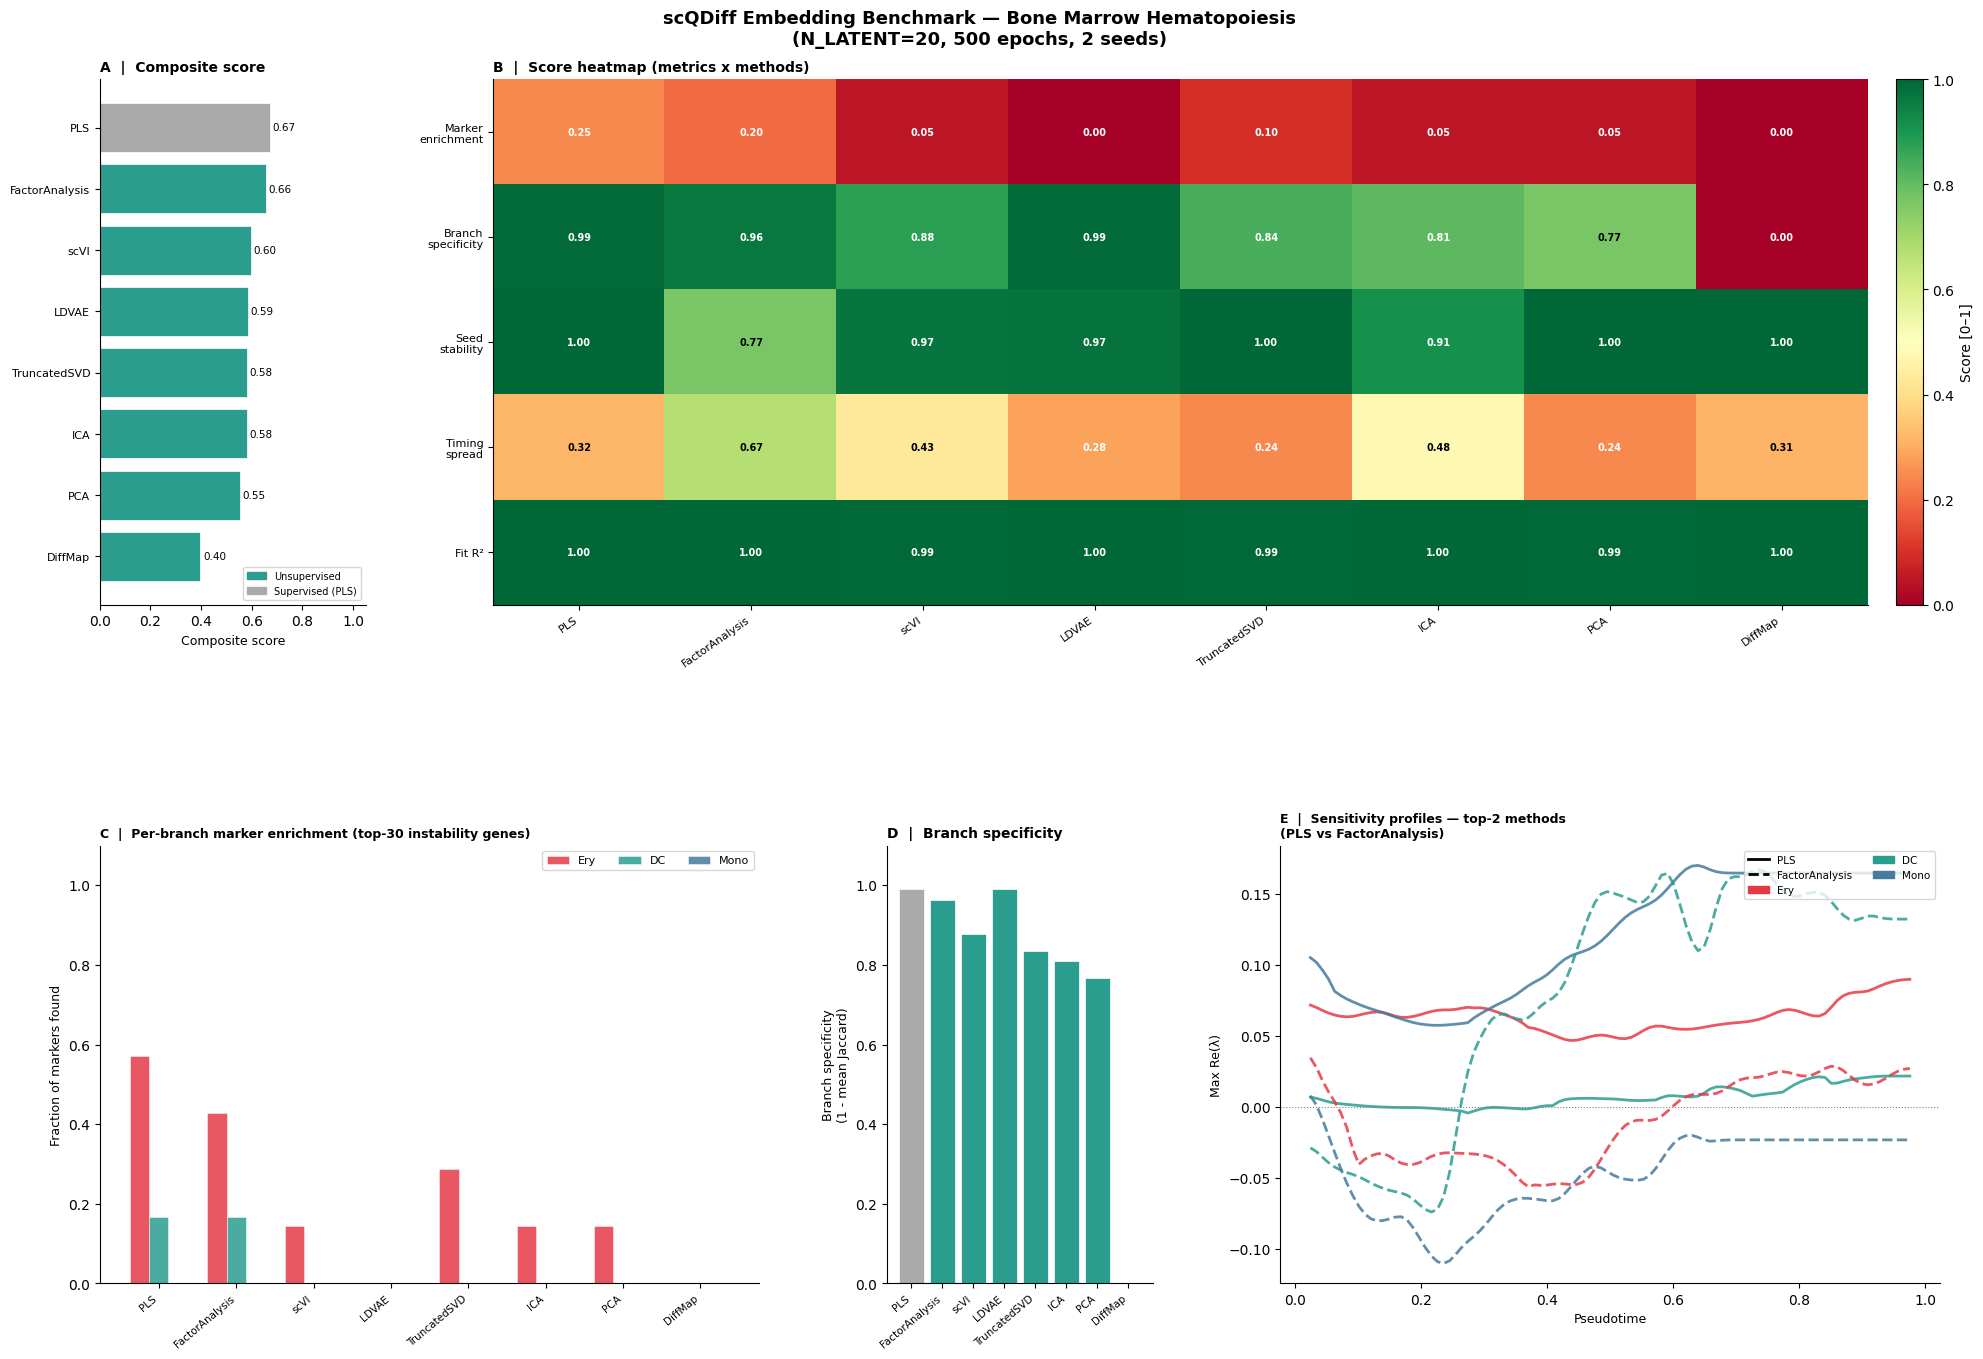

In [18]:
# ── Manuscript figure — 5 panels ──────────────────────────────────────────

METHODS_RANKED = [r['method']     for r in rows]
COMPOSITES     = [r['composite']  for r in rows]
SUPERVISED_SET = {r['method'] for r in rows if r['supervised']}

METRIC_NAMES = ['marker', 'specificity', 'stability', 'timing', 'r2']
METRIC_LABELS = {
    'marker':      'Marker\nenrichment',
    'specificity': 'Branch\nspecificity',
    'stability':   'Seed\nstability',
    'timing':      'Timing\nspread',
    'r2':          'Fit R²',
}

# ── Color helpers ─────────────────────────────────────────────────────────
def method_color(method_name):
    return '#AAAAAA' if method_name in SUPERVISED_SET else '#2A9D8F'

# ── Figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(
    2, 5,
    height_ratios=[1.2, 1.0],
    hspace=0.50,
    wspace=0.48,
    left=0.06, right=0.98, top=0.93, bottom=0.07
)

ax_A = fig.add_subplot(gs[0, 0])          # Panel A — composite bar
ax_B = fig.add_subplot(gs[0, 1:])         # Panel B — score heatmap (wide)
ax_C = fig.add_subplot(gs[1, 0:2])        # Panel C — per-branch marker
ax_D = fig.add_subplot(gs[1, 2])          # Panel D — specificity per method
ax_E = fig.add_subplot(gs[1, 3:])         # Panel E — sensitivity profiles

# ──────────────────────────────────────────────────────────────────────────
# Panel A — Composite score bar chart (best→worst, top-to-bottom)
# ──────────────────────────────────────────────────────────────────────────
n_methods = len(METHODS_RANKED)
y_pos     = np.arange(n_methods)
colors_A  = [method_color(m) for m in METHODS_RANKED]

ax_A.barh(y_pos, COMPOSITES, color=colors_A, edgecolor='white', linewidth=0.5)
ax_A.set_yticks(y_pos)
ax_A.set_yticklabels(METHODS_RANKED, fontsize=8)
ax_A.invert_yaxis()   # best method at top
ax_A.set_xlim(0, 1.05)
ax_A.set_xlabel('Composite score', fontsize=9)
ax_A.axvline(0, color='gray', lw=0.5)
for i, (m, v) in enumerate(zip(METHODS_RANKED, COMPOSITES)):
    ax_A.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=7.5)

# Legend: teal = unsupervised, gray = supervised
from matplotlib.patches import Patch
ax_A.legend(handles=[
    Patch(color='#2A9D8F', label='Unsupervised'),
    Patch(color='#AAAAAA', label='Supervised (PLS)'),
], fontsize=7, loc='lower right')
ax_A.set_title('A  |  Composite score', fontweight='bold', loc='left', fontsize=10)

# ──────────────────────────────────────────────────────────────────────────
# Panel B — Score heatmap: metrics (rows) x methods (cols)
# ──────────────────────────────────────────────────────────────────────────
heatmap_data = np.array([
    [r[metric] for r in rows] for metric in METRIC_NAMES
])   # shape (n_metrics, n_methods)

im = ax_B.imshow(heatmap_data, aspect='auto', vmin=0, vmax=1,
                  cmap='RdYlGn', interpolation='nearest')
ax_B.set_xticks(np.arange(n_methods))
ax_B.set_xticklabels(METHODS_RANKED, rotation=35, ha='right', fontsize=8)
ax_B.set_yticks(np.arange(len(METRIC_NAMES)))
ax_B.set_yticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], fontsize=8)

# Annotate each cell
for i in range(len(METRIC_NAMES)):
    for j in range(n_methods):
        val = heatmap_data[i, j]
        txt_color = 'black' if 0.3 < val < 0.8 else 'white'
        ax_B.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=7, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax_B, fraction=0.03, pad=0.02, label='Score [0–1]')
ax_B.set_title('B  |  Score heatmap (metrics x methods)', fontweight='bold',
                loc='left', fontsize=10)

# ──────────────────────────────────────────────────────────────────────────
# Panel C — Grouped bar chart: per-branch marker enrichment
# ──────────────────────────────────────────────────────────────────────────
branch_keys = ['marker_Ery', 'marker_DC', 'marker_Mono']
branch_labels = ['Ery', 'DC', 'Mono']
branch_bar_colors = [BRANCH_COLORS['Ery'], BRANCH_COLORS['DC'], BRANCH_COLORS['Mono']]

x_c     = np.arange(n_methods)
bar_w   = 0.25
offsets = [-bar_w, 0, bar_w]

for bi, (bk, bl, bc) in enumerate(zip(branch_keys, branch_labels, branch_bar_colors)):
    vals = [r[bk] for r in rows]
    ax_C.bar(x_c + offsets[bi], vals, width=bar_w, label=bl,
              color=bc, alpha=0.85, edgecolor='white', linewidth=0.4)

ax_C.set_xticks(x_c)
ax_C.set_xticklabels(METHODS_RANKED, rotation=40, ha='right', fontsize=7.5)
ax_C.set_ylabel('Fraction of markers found', fontsize=9)
ax_C.set_ylim(0, 1.1)
ax_C.legend(fontsize=8, ncol=3)
ax_C.axhline(0, color='gray', lw=0.5)
ax_C.set_title('C  |  Per-branch marker enrichment (top-30 instability genes)',
                fontweight='bold', loc='left', fontsize=9)

# ──────────────────────────────────────────────────────────────────────────
# Panel D — Branch specificity per method
# ──────────────────────────────────────────────────────────────────────────
spec_vals  = [r['specificity'] for r in rows]
colors_D   = [method_color(m) for m in METHODS_RANKED]

ax_D.bar(x_c, spec_vals, color=colors_D, edgecolor='white', linewidth=0.5)
ax_D.set_xticks(x_c)
ax_D.set_xticklabels(METHODS_RANKED, rotation=40, ha='right', fontsize=7.5)
ax_D.set_ylabel('Branch specificity\n(1 - mean Jaccard)', fontsize=9)
ax_D.set_ylim(0, 1.1)
ax_D.axhline(0, color='gray', lw=0.5)
ax_D.set_title('D  |  Branch specificity', fontweight='bold', loc='left', fontsize=10)

# ──────────────────────────────────────────────────────────────────────────
# Panel E — Sensitivity profiles for top-2 ranked methods
# ──────────────────────────────────────────────────────────────────────────
line_styles = ['-', '--']
top2 = rows[:2]  # already sorted best→worst

for mi, row in enumerate(top2):
    ls = line_styles[mi]
    method = row['method']
    t_curves   = row['_t_centers']
    eig_curves = row['_max_eig_curves']
    for branch in SHARED_BRANCH_NAMES:
        if branch not in t_curves:
            continue
        t   = t_curves[branch]
        eig = eig_curves[branch]
        col = BRANCH_COLORS.get(branch, '#555')
        label_str = f'{method} / {branch}' if mi == 0 else f'{method} / {branch}'
        ax_E.plot(t, eig, color=col, ls=ls, lw=2.0,
                   label=f'{method} – {branch}', alpha=0.85)

ax_E.axhline(0, color='gray', lw=0.8, ls=':')
ax_E.set_xlabel('Pseudotime', fontsize=9)
ax_E.set_ylabel('Max Re(λ)', fontsize=9)
top2_names = ' vs '.join(r['method'] for r in top2)
ax_E.set_title(f'E  |  Sensitivity profiles — top-2 methods\n({top2_names})',
                fontweight='bold', loc='left', fontsize=9)

# Custom legend: solid=rank-1, dashed=rank-2
from matplotlib.lines import Line2D
legend_handles = []
for mi, row in enumerate(top2):
    legend_handles.append(
        Line2D([0], [0], color='black', ls=line_styles[mi], lw=2,
               label=row['method'])
    )
for branch in SHARED_BRANCH_NAMES:
    legend_handles.append(
        Patch(color=BRANCH_COLORS.get(branch, '#555'), label=branch)
    )
ax_E.legend(handles=legend_handles, fontsize=7.5, ncol=2, loc='upper right')

# ── Final figure formatting ────────────────────────────────────────────────
fig.suptitle(
    'scJDO Embedding Benchmark — Bone Marrow Hematopoiesis\n'
    f'(N_LATENT={N_LATENT}, {N_EPOCHS} epochs, {N_SEEDS} seeds)',
    fontsize=13, fontweight='bold'
)

fig_path = OUTDIR + 'benchmark_figure.pdf'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

In [19]:
# ── Ranked summary table ───────────────────────────────────────────────────
print('=' * 90)
print(f'{"Rank":>4}  {"Method":18s}  {"Composite":>9}  {"Marker":>7}  '
      f'{"Specif":>7}  {"Stability":>9}  {"Timing":>7}  {"R2":>7}  {"Supervised":>10}')
print('-' * 90)

for rank, row in enumerate(rows, start=1):
    sup_str = 'Yes (PLS)' if row['supervised'] else ''
    print(
        f'{rank:>4}  {row["method"]:18s}  '
        f'{row["composite"]:>9.3f}  '
        f'{row["marker"]:>7.3f}  '
        f'{row["specificity"]:>7.3f}  '
        f'{row["stability"]:>9.3f}  '
        f'{row["timing"]:>7.3f}  '
        f'{row["r2"]:>7.3f}  '
        f'{sup_str:>10}'
    )

print('=' * 90)
print()
print('Score weights: marker=30%, specificity=20%, stability=20%, timing=15%, R²=15%')
print()
print('Notes:')
print('  - PLS is supervised (uses pseudotime as regression target)')
print('  - Stability = 1.0 for deterministic methods (TruncatedSVD, DiffMap, PLS)')
print('  - DiffMap skips DC0 (uniform eigenvector); uses columns 1..N_LATENT')
print('  - LDVAE and scVI use raw_counts layer with NB likelihood')
print('  - Ridge regression used for DiffMap and scVI gene loadings')
print()
print(f'Files written to: {OUTDIR}')
import pathlib
for f in sorted(pathlib.Path(OUTDIR).iterdir()):
    print(f'  {f.name}')

Rank  Method              Composite   Marker   Specif  Stability   Timing       R2  Supervised
------------------------------------------------------------------------------------------
   1  PLS                     0.670    0.246    0.991      1.000    0.317    0.999   Yes (PLS)
   2  FactorAnalysis          0.656    0.198    0.963      0.768    0.671    0.999            
   3  scVI                    0.597    0.048    0.878      0.969    0.426    0.995            
   4  LDVAE                   0.586    0.000    0.991      0.975    0.285    0.997            
   5  TruncatedSVD            0.582    0.095    0.836      1.000    0.245    0.995            
   6  ICA                     0.580    0.048    0.809      0.911    0.480    0.999            
   7  PCA                     0.553    0.048    0.767      1.000    0.245    0.993            
   8  DiffMap                 0.397    0.000    0.000      1.000    0.313    1.000            

Score weights: marker=30%, specificity=20%, stability